In [1]:
!pip -q install torchmetrics torch-fidelity thop

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 5.7 MB/s eta 0:00:00


In [2]:
import os
import math
import json
import time
import copy
import random
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, utils
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from thop import profile
from torchmetrics.image.fid import FrechetInceptionDistance

In [3]:
def seed_all(seed=42):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_all(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
print("Torch version:", torch.__version__)

Device: cuda
Torch version: 2.10.0+cu128


In [4]:
# Change this only if your Kaggle CelebA path is different
DATA_ROOT = Path("/kaggle/input/datasets/jessicali9530/celeba-dataset/img_align_celeba/img_align_celeba")

WORK_ROOT = Path("/kaggle/working/cse499b_celeba_inpainting")

CKPT_DIR   = WORK_ROOT / "checkpoints"
RESULT_DIR = WORK_ROOT / "results"
SAMPLE_DIR = WORK_ROOT / "samples"
CONFIG_DIR = WORK_ROOT / "configs"

for p in [CKPT_DIR, RESULT_DIR, SAMPLE_DIR, CONFIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("DATA_ROOT :", DATA_ROOT)
print("WORK_ROOT :", WORK_ROOT)
print("CKPT_DIR  :", CKPT_DIR)
print("RESULT_DIR:", RESULT_DIR)
print("SAMPLE_DIR:", SAMPLE_DIR)
print("CONFIG_DIR:", CONFIG_DIR)

DATA_ROOT : /kaggle/input/datasets/jessicali9530/celeba-dataset/img_align_celeba/img_align_celeba
WORK_ROOT : /kaggle/working/cse499b_celeba_inpainting
CKPT_DIR  : /kaggle/working/cse499b_celeba_inpainting/checkpoints
RESULT_DIR: /kaggle/working/cse499b_celeba_inpainting/results
SAMPLE_DIR: /kaggle/working/cse499b_celeba_inpainting/samples
CONFIG_DIR: /kaggle/working/cse499b_celeba_inpainting/configs


In [5]:
BASE = {
    "dataset": "CELEBA_IMAGEFOLDER",
    "image_size": 64,
    "image_channels": 3,
    "cond_channels": 4,
    "batch_size": 32,
    "num_workers": 2,

    "T": 1000,
    "beta_start": 1e-4,
    "beta_end": 0.02,

    "epochs": 20,
    "lr": 2e-4,
    "weight_decay": 0.0,
    "grad_clip": 1.0,

    "ema": {
        "use": True,
        "decay": 0.999
    },

    "sample": {
        "n_samples": 8,
        "grid_rows": 4,
        "ddim_steps": 50,
        "ddim_eta": 0.0
    },

    "eval": {
        "fid_real_limit": 1000,
        "fid_fake_limit": 1000,
        "speed_n_images": 32
    },

    "masking": {
        "min_holes": 1,
        "max_holes": 4,
        "min_size": 8,
        "max_size": 28
    },

    "split": {
        "train_size": 10000,
        "val_size": 1000,
        "test_size": 1000,
        "seed": 42
    },

    "save_policy": {
        "save_latest": True,
        "save_best": True,
        "save_milestones": [],
        "save_ema_final": True
    }
}

In [6]:
EXPS = {}

EXPS["old_baseline_inpaint_celeba"] = copy.deepcopy(BASE)
EXPS["old_baseline_inpaint_celeba"].update({
    "model": {
        "base_ch": 64,
        "ch_mults": [1, 2, 4, 8],
        "num_res_blocks": 2,
        "attn_resolutions": [16, 8],
        "time_dim": 256,
        "use_depthwise_mode": "none"
    }
})

EXPS["variantA_inpaint_celeba"] = copy.deepcopy(BASE)
EXPS["variantA_inpaint_celeba"].update({
    "model": {
        "base_ch": 48,
        "ch_mults": [1, 2, 3, 4],
        "num_res_blocks": 1,
        "attn_resolutions": [8],
        "time_dim": 128,
        "use_depthwise_mode": "mid"
    }
})

EXPS["variantB_inpaint_celeba"] = copy.deepcopy(BASE)
EXPS["variantB_inpaint_celeba"].update({
    "model": {
        "base_ch": 32,
        "ch_mults": [1, 2, 3, 4],
        "num_res_blocks": 1,
        "attn_resolutions": [8],
        "time_dim": 128,
        "use_depthwise_mode": "all_internal"
    }
})

for name, cfg in EXPS.items():
    with open(CONFIG_DIR / f"{name}.json", "w") as f:
        json.dump(cfg, f, indent=2)

print("Saved configs.")

Saved configs.


In [7]:
EXP_NAME = "old_baseline_inpaint_celeba"   # change this later
cfg = EXPS[EXP_NAME]
print("Selected experiment:", EXP_NAME)

Selected experiment: old_baseline_inpaint_celeba


In [8]:
class FlatImageFolderDataset(Dataset):
    def __init__(self, image_root, image_size=64):
        self.image_root = Path(image_root)
        self.paths = sorted([
            p for p in self.image_root.glob("*")
            if p.suffix.lower() in [".jpg", ".jpeg", ".png", ".webp"]
        ])

        self.transform = transforms.Compose([
            transforms.CenterCrop(178),
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Lambda(lambda x: x * 2 - 1)
        ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        img = self.transform(img)
        return img

full_ds = FlatImageFolderDataset(DATA_ROOT, image_size=cfg["image_size"])
print("Total images found:", len(full_ds))

Total images found: 202599


In [9]:
def fixed_split_dataset(dataset, train_size=10000, val_size=1000, test_size=1000, seed=42):
    n = len(dataset)
    total_needed = train_size + val_size + test_size

    if total_needed > n:
        raise ValueError(f"Requested {total_needed} images, but dataset has only {n}")

    idxs = list(range(n))
    random.Random(seed).shuffle(idxs)

    train_idxs = idxs[:train_size]
    val_idxs = idxs[train_size:train_size + val_size]
    test_idxs = idxs[train_size + val_size:train_size + val_size + test_size]

    class SubsetDataset(Dataset):
        def __init__(self, base_ds, indices):
            self.base_ds = base_ds
            self.indices = indices

        def __len__(self):
            return len(self.indices)

        def __getitem__(self, i):
            return self.base_ds[self.indices[i]]

    return (
        SubsetDataset(dataset, train_idxs),
        SubsetDataset(dataset, val_idxs),
        SubsetDataset(dataset, test_idxs)
    )

train_base, val_base, test_base = fixed_split_dataset(
    full_ds,
    train_size=cfg["split"]["train_size"],
    val_size=cfg["split"]["val_size"],
    test_size=cfg["split"]["test_size"],
    seed=cfg["split"]["seed"]
)

print("Train size:", len(train_base))
print("Val size  :", len(val_base))
print("Test size :", len(test_base))

Train size: 10000
Val size  : 1000
Test size : 1000


In [10]:
def make_random_rect_mask(h, w, min_holes=1, max_holes=4, min_size=8, max_size=28):
    mask = torch.zeros(1, h, w)
    n_holes = random.randint(min_holes, max_holes)

    for _ in range(n_holes):
        hole_h = random.randint(min_size, max_size)
        hole_w = random.randint(min_size, max_size)
        y = random.randint(0, h - hole_h)
        x = random.randint(0, w - hole_w)
        mask[:, y:y+hole_h, x:x+hole_w] = 1.0

    return mask

In [11]:
class CelebAInpaintingDataset(Dataset):
    def __init__(self, base_dataset, mask_cfg):
        self.base_dataset = base_dataset
        self.mask_cfg = mask_cfg

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        img = self.base_dataset[idx]
        _, h, w = img.shape

        mask = make_random_rect_mask(
            h, w,
            min_holes=self.mask_cfg["min_holes"],
            max_holes=self.mask_cfg["max_holes"],
            min_size=self.mask_cfg["min_size"],
            max_size=self.mask_cfg["max_size"]
        )

        masked_img = img * (1.0 - mask)

        return {
            "image": img,
            "mask": mask,
            "masked_image": masked_img
        }

def get_dataloaders(cfg):
    trainset = CelebAInpaintingDataset(train_base, cfg["masking"])
    valset   = CelebAInpaintingDataset(val_base, cfg["masking"])
    testset  = CelebAInpaintingDataset(test_base, cfg["masking"])

    trainloader = DataLoader(
        trainset,
        batch_size=cfg["batch_size"],
        shuffle=True,
        num_workers=cfg["num_workers"],
        pin_memory=True,
        drop_last=True
    )

    valloader = DataLoader(
        valset,
        batch_size=cfg["batch_size"],
        shuffle=False,
        num_workers=cfg["num_workers"],
        pin_memory=True,
        drop_last=False
    )

    testloader = DataLoader(
        testset,
        batch_size=cfg["batch_size"],
        shuffle=False,
        num_workers=cfg["num_workers"],
        pin_memory=True,
        drop_last=False
    )

    return trainloader, valloader, testloader

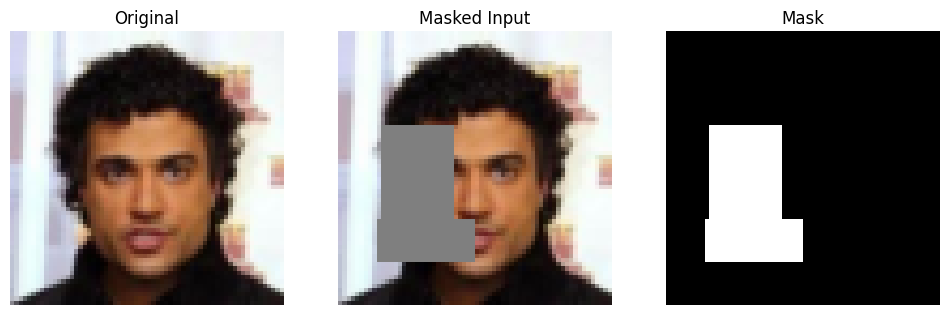

In [12]:
trainloader, valloader, testloader = get_dataloaders(cfg)
batch = next(iter(trainloader))

img = (batch["image"][0] + 1) / 2
masked = (batch["masked_image"][0] + 1) / 2
mask = batch["mask"][0].repeat(3, 1, 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img.permute(1, 2, 0))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(masked.permute(1, 2, 0))
plt.title("Masked Input")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(mask.permute(1, 2, 0))
plt.title("Mask")
plt.axis("off")

plt.show()

In [13]:
def make_beta_schedule(T, beta_start, beta_end):
    return torch.linspace(beta_start, beta_end, T)

class Diffusion:
    def __init__(self, T=1000, beta_start=1e-4, beta_end=0.02, device="cuda"):
        self.T = T
        self.device = device

        self.betas = make_beta_schedule(T, beta_start, beta_end).to(device)
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.alphas_cumprod_prev = torch.cat(
            [torch.tensor([1.0], device=device), self.alphas_cumprod[:-1]], dim=0
        )

        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)
        self.posterior_variance = (
            self.betas * (1.0 - self.alphas_cumprod_prev) / (1.0 - self.alphas_cumprod)
        )

    def sample_timesteps(self, n):
        return torch.randint(low=0, high=self.T, size=(n,), device=self.device)

    def noise_images(self, x, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x)
        sqrt_ac = self.sqrt_alphas_cumprod[t][:, None, None, None]
        sqrt_om = self.sqrt_one_minus_alphas_cumprod[t][:, None, None, None]
        return sqrt_ac * x + sqrt_om * noise, noise

In [14]:
class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, p=1):
        super().__init__()
        self.dw = nn.Conv2d(in_ch, in_ch, kernel_size=k, padding=p, groups=in_ch, bias=False)
        self.pw = nn.Conv2d(in_ch, out_ch, kernel_size=1, bias=False)

    def forward(self, x):
        return self.pw(self.dw(x))

def conv3x3(in_ch, out_ch, mode="standard"):
    if mode == "depthwise":
        return DepthwiseSeparableConv(in_ch, out_ch, 3, 1)
    return nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)

class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half = self.dim // 2
        emb = math.log(10000) / max(half - 1, 1)
        emb = torch.exp(torch.arange(half, device=t.device) * -emb)
        emb = t[:, None].float() * emb[None, :]
        emb = torch.cat([emb.sin(), emb.cos()], dim=1)
        return emb

class TimeMLP(nn.Module):
    def __init__(self, time_dim):
        super().__init__()
        self.net = nn.Sequential(
            SinusoidalPosEmb(time_dim),
            nn.Linear(time_dim, time_dim * 2),
            nn.SiLU(),
            nn.Linear(time_dim * 2, time_dim)
        )

    def forward(self, t):
        return self.net(t)

class SelfAttention2d(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.norm = nn.GroupNorm(8, ch)
        self.q = nn.Conv2d(ch, ch, 1)
        self.k = nn.Conv2d(ch, ch, 1)
        self.v = nn.Conv2d(ch, ch, 1)
        self.proj = nn.Conv2d(ch, ch, 1)

    def forward(self, x):
        b, c, h, w = x.shape
        h_in = x
        x = self.norm(x)

        q = self.q(x).reshape(b, c, h * w).permute(0, 2, 1)
        k = self.k(x).reshape(b, c, h * w)
        v = self.v(x).reshape(b, c, h * w).permute(0, 2, 1)

        attn = torch.bmm(q, k) * (c ** -0.5)
        attn = torch.softmax(attn, dim=-1)

        out = torch.bmm(attn, v).permute(0, 2, 1).reshape(b, c, h, w)
        out = self.proj(out)
        return h_in + out

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim, conv_mode="standard", use_attn=False):
        super().__init__()
        self.norm1 = nn.GroupNorm(8, in_ch)
        self.act1 = nn.SiLU()
        self.conv1 = conv3x3(in_ch, out_ch, mode=conv_mode)

        self.time_proj = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_dim, out_ch)
        )

        self.norm2 = nn.GroupNorm(8, out_ch)
        self.act2 = nn.SiLU()
        self.conv2 = conv3x3(out_ch, out_ch, mode=conv_mode)

        self.shortcut = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        self.attn = SelfAttention2d(out_ch) if use_attn else nn.Identity()

    def forward(self, x, t_emb):
        h = self.conv1(self.act1(self.norm1(x)))
        h = h + self.time_proj(t_emb)[:, :, None, None]
        h = self.conv2(self.act2(self.norm2(h)))
        h = h + self.shortcut(x)
        h = self.attn(h)
        return h

class Downsample(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv = nn.Conv2d(ch, ch, kernel_size=4, stride=2, padding=1)

    def forward(self, x):
        return self.conv(x)

class Upsample(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv = nn.Conv2d(ch, ch, kernel_size=3, padding=1)

    def forward(self, x):
        x = F.interpolate(x, scale_factor=2, mode="nearest")
        return self.conv(x)

In [15]:
class UNetInpaintDiffusion(nn.Module):
    def __init__(
        self,
        x_channels=3,
        cond_channels=4,
        out_channels=3,
        image_size=64,
        base_ch=64,
        ch_mults=[1,2,4,8],
        num_res_blocks=2,
        time_dim=256,
        attn_resolutions=[16,8],
        use_depthwise_mode="none"
    ):
        super().__init__()

        self.time_mlp = TimeMLP(time_dim)
        in_channels = x_channels + cond_channels
        self.in_conv = nn.Conv2d(in_channels, base_ch, kernel_size=3, padding=1)

        chs = [base_ch * m for m in ch_mults]
        self.down_blocks = nn.ModuleList()
        self.downsamples = nn.ModuleList()
        self.skip_channels = []

        cur_ch = base_ch
        cur_res = image_size

        for i, ch in enumerate(chs):
            stage = nn.ModuleList()
            for _ in range(num_res_blocks):
                if use_depthwise_mode == "none":
                    conv_mode = "standard"
                elif use_depthwise_mode == "mid":
                    conv_mode = "depthwise" if (i > 0 and i < len(chs)-1) else "standard"
                else:
                    conv_mode = "depthwise"

                use_attn = cur_res in attn_resolutions
                block = ResBlock(cur_ch, ch, time_dim, conv_mode=conv_mode, use_attn=use_attn)
                stage.append(block)
                cur_ch = ch
                self.skip_channels.append(cur_ch)

            self.down_blocks.append(stage)

            if i != len(chs) - 1:
                self.downsamples.append(Downsample(cur_ch))
                cur_res //= 2

        self.mid_block1 = ResBlock(cur_ch, cur_ch, time_dim, conv_mode="standard", use_attn=True)
        self.mid_block2 = ResBlock(cur_ch, cur_ch, time_dim, conv_mode="standard", use_attn=False)

        self.up_blocks = nn.ModuleList()
        self.upsamples = nn.ModuleList()

        rev_chs = list(reversed(chs))
        rev_skip = list(reversed(self.skip_channels))
        cur_res = image_size // (2 ** (len(chs) - 1))

        for i, ch in enumerate(rev_chs):
            stage = nn.ModuleList()
            for _ in range(num_res_blocks):
                skip_ch = rev_skip.pop(0)

                if use_depthwise_mode == "none":
                    conv_mode = "standard"
                elif use_depthwise_mode == "mid":
                    conv_mode = "depthwise" if (i > 0 and i < len(rev_chs)-1) else "standard"
                else:
                    conv_mode = "depthwise"

                use_attn = cur_res in attn_resolutions
                block = ResBlock(cur_ch + skip_ch, ch, time_dim, conv_mode=conv_mode, use_attn=use_attn)
                stage.append(block)
                cur_ch = ch

            self.up_blocks.append(stage)

            if i < len(rev_chs) - 1:
                self.upsamples.append(Upsample(cur_ch))
                cur_res *= 2

        self.out_norm = nn.GroupNorm(8, cur_ch)
        self.out_act = nn.SiLU()
        self.out_conv = nn.Conv2d(cur_ch, out_channels, kernel_size=3, padding=1)

    def forward(self, x_t, cond, t):
        t_emb = self.time_mlp(t)

        x = torch.cat([x_t, cond], dim=1)
        x = self.in_conv(x)

        skips = []
        for i, stage in enumerate(self.down_blocks):
            for block in stage:
                x = block(x, t_emb)
                skips.append(x)
            if i < len(self.downsamples):
                x = self.downsamples[i](x)

        x = self.mid_block1(x, t_emb)
        x = self.mid_block2(x, t_emb)

        for i, stage in enumerate(self.up_blocks):
            for block in stage:
                skip = skips.pop()
                x = torch.cat([x, skip], dim=1)
                x = block(x, t_emb)
            if i < len(self.upsamples):
                x = self.upsamples[i](x)

        x = self.out_conv(self.out_act(self.out_norm(x)))
        return x

def build_model_from_cfg(cfg):
    mcfg = cfg["model"]
    return UNetInpaintDiffusion(
        x_channels=cfg["image_channels"],
        cond_channels=cfg["cond_channels"],
        out_channels=cfg["image_channels"],
        image_size=cfg["image_size"],
        base_ch=mcfg["base_ch"],
        ch_mults=mcfg["ch_mults"],
        num_res_blocks=mcfg["num_res_blocks"],
        time_dim=mcfg["time_dim"],
        attn_resolutions=mcfg["attn_resolutions"],
        use_depthwise_mode=mcfg["use_depthwise_mode"]
    ).to(device)

In [16]:
class EMA:
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = {k: v.detach().clone() for k, v in model.state_dict().items()}

    @torch.no_grad()
    def update(self, model):
        for k, v in model.state_dict().items():
            self.shadow[k].mul_(self.decay).add_(v.detach(), alpha=1 - self.decay)

def milestone_full_path(exp_name, epoch):
    return CKPT_DIR / f"{exp_name}_epoch{epoch}.pt"

def latest_full_path(exp_name):
    return CKPT_DIR / f"{exp_name}_latest_full.pt"

def best_full_path(exp_name):
    return CKPT_DIR / f"{exp_name}_best_full.pt"

def ema_path(exp_name):
    return CKPT_DIR / f"{exp_name}_ema_final.pt"

def trainlog_path(exp_name):
    return RESULT_DIR / f"{exp_name}_trainlog.json"

def evaljson_path(exp_name):
    return RESULT_DIR / f"{exp_name}_single_eval.json"

def evalcsv_path(exp_name):
    return RESULT_DIR / f"{exp_name}_single_eval.csv"

def save_json(obj, path):
    with open(path, "w") as f:
        json.dump(obj, f, indent=2)

def load_json(path, default=None):
    if Path(path).exists():
        with open(path, "r") as f:
            return json.load(f)
    return default

In [17]:
@torch.no_grad()
def ddim_inpaint_sample(model, diff, masked_img, mask, steps=50, eta=0.0):
    model.eval()
    b = masked_img.size(0)

    cond = torch.cat([masked_img, mask], dim=1)
    x = torch.randn_like(masked_img)

    times = torch.linspace(diff.T - 1, 0, steps, device=diff.device).long()

    for idx, i in enumerate(times):
        t = torch.full((b,), i.item(), device=diff.device, dtype=torch.long)

        known_noisy, _ = diff.noise_images(masked_img, t, noise=torch.zeros_like(masked_img))
        x = x * mask + known_noisy * (1.0 - mask)

        eps = model(x, cond, t)

        alpha_hat = diff.alphas_cumprod[i]
        sqrt_alpha_hat = torch.sqrt(alpha_hat)
        sqrt_one_minus_alpha_hat = torch.sqrt(1 - alpha_hat)

        x0_pred = (x - sqrt_one_minus_alpha_hat * eps) / sqrt_alpha_hat
        x0_pred = torch.clamp(x0_pred, -1, 1)

        if idx == len(times) - 1:
            x = x0_pred
        else:
            next_i = times[idx + 1]
            alpha_hat_next = diff.alphas_cumprod[next_i]

            sigma = eta * torch.sqrt(
                (1 - alpha_hat_next) / (1 - alpha_hat) * (1 - alpha_hat / alpha_hat_next)
            )
            noise = torch.randn_like(x) if eta > 0 else torch.zeros_like(x)

            x = (
                torch.sqrt(alpha_hat_next) * x0_pred +
                torch.sqrt(torch.clamp(1 - alpha_hat_next - sigma**2, min=0.0)) * eps +
                sigma * noise
            )

    final = masked_img * (1.0 - mask) + x * mask
    return final

def to_01(x):
    return (x.clamp(-1, 1) + 1) / 2

In [18]:
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def compute_params_macs(model, cfg):
    dummy_x = torch.randn(1, cfg["image_channels"], cfg["image_size"], cfg["image_size"]).to(device)
    dummy_cond = torch.randn(1, cfg["cond_channels"], cfg["image_size"], cfg["image_size"]).to(device)
    dummy_t = torch.randint(0, cfg["T"], (1,), device=device)
    macs, params = profile(model, inputs=(dummy_x, dummy_cond, dummy_t), verbose=False)
    return params, macs

@torch.no_grad()
def measure_sampling_speed(model, diff, cfg, testloader):
    n_imgs = cfg["eval"]["speed_n_images"]
    done = 0
    start = time.time()

    for batch in testloader:
        mask = batch["mask"].to(device)
        masked = batch["masked_image"].to(device)

        _ = ddim_inpaint_sample(
            model, diff, masked, mask,
            steps=cfg["sample"]["ddim_steps"],
            eta=cfg["sample"]["ddim_eta"]
        )

        done += mask.size(0)
        if done >= n_imgs:
            break

    elapsed = time.time() - start
    return elapsed / max(done, 1)

@torch.no_grad()
def compute_fid(model, diff, cfg, testloader):
    fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)

    real_limit = cfg["eval"]["fid_real_limit"]
    fake_limit = cfg["eval"]["fid_fake_limit"]

    real_seen = 0
    for batch in tqdm(testloader, desc="FID real"):
        imgs = batch["image"].to(device)
        fid.update(to_01(imgs), real=True)
        real_seen += imgs.size(0)
        if real_seen >= real_limit:
            break

    fake_seen = 0
    for batch in tqdm(testloader, desc="FID fake"):
        mask = batch["mask"].to(device)
        masked = batch["masked_image"].to(device)

        out = ddim_inpaint_sample(
            model, diff, masked, mask,
            steps=cfg["sample"]["ddim_steps"],
            eta=cfg["sample"]["ddim_eta"]
        )
        fid.update(to_01(out), real=False)

        fake_seen += out.size(0)
        if fake_seen >= fake_limit:
            break

    return float(fid.compute().item())

@torch.no_grad()
def save_sample_grid(model, diff, cfg, testloader, out_path, n_samples=8):
    batch = next(iter(testloader))
    img = batch["image"][:n_samples].to(device)
    mask = batch["mask"][:n_samples].to(device)
    masked = batch["masked_image"][:n_samples].to(device)

    out = ddim_inpaint_sample(
        model, diff, masked, mask,
        steps=cfg["sample"]["ddim_steps"],
        eta=cfg["sample"]["ddim_eta"]
    )

    rows = []
    for i in range(n_samples):
        rows.extend([
            to_01(img[i]),
            to_01(masked[i]),
            mask[i].repeat(3, 1, 1),
            to_01(out[i])
        ])

    grid = utils.make_grid(torch.stack(rows), nrow=4)
    utils.save_image(grid, out_path)

In [19]:
@torch.no_grad()
def evaluate_val_loss(model, diff, valloader):
    model.eval()
    total_loss = 0.0
    total_batches = 0

    for batch in valloader:
        image = batch["image"].to(device)
        mask = batch["mask"].to(device)
        masked_image = batch["masked_image"].to(device)

        cond = torch.cat([masked_image, mask], dim=1)
        t = diff.sample_timesteps(image.size(0))
        x_t, noise = diff.noise_images(image, t)

        pred = model(x_t, cond, t)
        hole_weight = 1.0 + 4.0 * mask
        loss_map = (pred - noise) ** 2
        loss = (loss_map * hole_weight).mean()

        total_loss += loss.item()
        total_batches += 1

    return total_loss / max(total_batches, 1)

In [20]:
def train_one_experiment(exp_name, cfg, resume=True):
    print(f"\n========== TRAINING: {exp_name} ==========")

    trainloader, valloader, testloader = get_dataloaders(cfg)
    model = build_model_from_cfg(cfg)
    diff = Diffusion(
        T=cfg["T"],
        beta_start=cfg["beta_start"],
        beta_end=cfg["beta_end"],
        device=device
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=cfg["lr"],
        weight_decay=cfg["weight_decay"]
    )

    scaler = torch.cuda.amp.GradScaler(enabled=(device == "cuda"))
    ema = EMA(model, decay=cfg["ema"]["decay"]) if cfg["ema"]["use"] else None

    log_data = load_json(trainlog_path(exp_name), default=[])
    start_epoch = 1
    best_val_loss = 1e18

    if resume and latest_full_path(exp_name).exists():
        ckpt = torch.load(latest_full_path(exp_name), map_location=device)
        model.load_state_dict(ckpt["model"])
        optimizer.load_state_dict(ckpt["optimizer"])
        start_epoch = ckpt["epoch"] + 1
        best_val_loss = ckpt.get("best_val_loss", 1e18)
        print(f"Resumed from epoch {ckpt['epoch']}")

        if cfg["ema"]["use"] and ema_path(exp_name).exists():
            ema_ckpt = torch.load(ema_path(exp_name), map_location=device)
            ema.shadow = ema_ckpt["shadow"]

    for epoch in range(start_epoch, cfg["epochs"] + 1):
        model.train()
        running_loss = 0.0
        pbar = tqdm(trainloader, desc=f"{exp_name} | Epoch {epoch}/{cfg['epochs']}")

        for batch in pbar:
            image = batch["image"].to(device)
            mask = batch["mask"].to(device)
            masked_image = batch["masked_image"].to(device)

            cond = torch.cat([masked_image, mask], dim=1)

            t = diff.sample_timesteps(image.size(0))
            x_t, noise = diff.noise_images(image, t)

            optimizer.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(enabled=(device == "cuda")):
                pred = model(x_t, cond, t)
                hole_weight = 1.0 + 4.0 * mask
                loss_map = (pred - noise) ** 2
                loss = (loss_map * hole_weight).mean()

            scaler.scale(loss).backward()

            if cfg["grad_clip"] is not None:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg["grad_clip"])

            scaler.step(optimizer)
            scaler.update()

            if ema is not None:
                ema.update(model)

            running_loss += loss.item()
            pbar.set_postfix(loss=f"{loss.item():.4f}")

        train_loss = running_loss / len(trainloader)

        val_model = build_model_from_cfg(cfg)
        val_model.load_state_dict(model.state_dict())
        if ema is not None:
            val_model.load_state_dict(ema.shadow)

        val_loss = evaluate_val_loss(val_model, diff, valloader)

        log_data = [x for x in log_data if x["epoch"] != epoch]
        log_data.append({
            "epoch": epoch,
            "train_loss": round(train_loss, 6),
            "val_loss": round(val_loss, 6)
        })
        log_data = sorted(log_data, key=lambda x: x["epoch"])
        save_json(log_data, trainlog_path(exp_name))

        state = {
            "epoch": epoch,
            "model": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "cfg": cfg,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "best_val_loss": min(best_val_loss, val_loss)
        }

        if cfg["save_policy"]["save_latest"]:
            torch.save(state, latest_full_path(exp_name))

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            if cfg["save_policy"]["save_best"]:
                torch.save(state, best_full_path(exp_name))

        if epoch in cfg["save_policy"]["save_milestones"]:
            torch.save(state, milestone_full_path(exp_name, epoch))

        if ema is not None and cfg["save_policy"]["save_ema_final"]:
            torch.save({"epoch": epoch, "shadow": ema.shadow}, ema_path(exp_name))

        print(f"Epoch {epoch} done | train loss = {train_loss:.6f} | val loss = {val_loss:.6f}")

    return model, diff, trainloader, valloader, testloader

In [21]:
model, diff, trainloader, valloader, testloader = train_one_experiment(EXP_NAME, cfg, resume=True)
print("Training finished:", EXP_NAME)


========== TRAINING: old_baseline_inpaint_celeba ==========


/tmp/ipykernel_55/3282740439.py:19: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device == "cuda"))
old_baseline_inpaint_celeba | Epoch 1/20:   0%|          | 0/312 [00:00<?, ?it/s]/tmp/ipykernel_55/3282740439.py:55: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device == "cuda")):
old_baseline_inpaint_celeba | Epoch 1/20: 100%|██████████| 312/312 [01:18<00:00,  3.97it/s, loss=0.0864]


Epoch 1 done | train loss = 0.135864 | val loss = 0.813018


old_baseline_inpaint_celeba | Epoch 2/20: 100%|██████████| 312/312 [01:22<00:00,  3.78it/s, loss=0.0369]


Epoch 2 done | train loss = 0.041759 | val loss = 0.252464


...

Epoch 18 done | train loss = 0.022545 | val loss = 0.019972


old_baseline_inpaint_celeba | Epoch 19/20: 100%|██████████| 312/312 [01:22<00:00,  3.79it/s, loss=0.0205]


Epoch 19 done | train loss = 0.019671 | val loss = 0.021400


old_baseline_inpaint_celeba | Epoch 20/20: 100%|██████████| 312/312 [01:22<00:00,  3.79it/s, loss=0.0220]


Epoch 20 done | train loss = 0.020338 | val loss = 0.018564
Training finished: old_baseline_inpaint_celeba


In [22]:
def load_eval_model(exp_name):
    cfg = copy.deepcopy(EXPS[exp_name])
    model = build_model_from_cfg(cfg)

    use_ema = False

    if ema_path(exp_name).exists():
        ckpt = torch.load(ema_path(exp_name), map_location=device)
        model.load_state_dict(ckpt["shadow"])
        use_ema = True
        print(f"{exp_name}: using EMA final")
    elif best_full_path(exp_name).exists():
        ckpt = torch.load(best_full_path(exp_name), map_location=device)
        model.load_state_dict(ckpt["model"])
        print(f"{exp_name}: using BEST checkpoint")
    else:
        ckpt = torch.load(latest_full_path(exp_name), map_location=device)
        model.load_state_dict(ckpt["model"])
        print(f"{exp_name}: using LATEST checkpoint")

    diff = Diffusion(
        T=cfg["T"],
        beta_start=cfg["beta_start"],
        beta_end=cfg["beta_end"],
        device=device
    )

    return model.eval(), diff, cfg, use_ema

In [23]:
results = []

model, diff, cfg, use_ema = load_eval_model(EXP_NAME)
_, _, testloader = get_dataloaders(cfg)

params = count_params(model)
thop_params, macs = compute_params_macs(model, cfg)
speed = measure_sampling_speed(model, diff, cfg, testloader)
fid = compute_fid(model, diff, cfg, testloader)

sample_path = SAMPLE_DIR / f"{EXP_NAME}_grid.png"
save_sample_grid(model, diff, cfg, testloader, sample_path, n_samples=8)

train_log = load_json(trainlog_path(EXP_NAME), default=[])
final_train_loss = train_log[-1]["train_loss"] if len(train_log) > 0 else None
final_val_loss = train_log[-1]["val_loss"] if len(train_log) > 0 else None

row = {
    "exp_name": EXP_NAME,
    "used_ema": use_ema,
    "params": int(params),
    "params_million": round(params / 1e6, 4),
    "thop_params": int(thop_params),
    "macs": int(macs),
    "macs_billion": round(macs / 1e9, 4),
    "fid": round(fid, 4),
    "sec_per_img": round(speed, 6),
    "final_train_loss": final_train_loss,
    "final_val_loss": final_val_loss,
    "sample_path": str(sample_path)
}

results.append(row)
df_results = pd.DataFrame(results)
df_results

old_baseline_inpaint_celeba: using EMA final


Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 358MB/s]
FID fake:  97%|█████████▋| 31/32 [03:40<00:07,  7.13s/it]


,exp_name,used_ema,params,params_million,thop_params,macs,macs_billion,fid,sec_per_img,final_train_loss,final_val_loss,sample_path
0,old_baseline_inpaint_celeba,True,53990019,53.99,53959427,9856548864,9.8565,135.4702,0.23057,0.020338,0.018564,/kaggle/working/cse499b_celeba_inpainting/samp...


In [24]:
single_result_csv = evalcsv_path(EXP_NAME)
single_result_json = evaljson_path(EXP_NAME)

df_results.to_csv(single_result_csv, index=False)
save_json(results, single_result_json)

print("Saved:", single_result_csv)
print("Saved:", single_result_json)
print("Sample image:", sample_path)

Saved: /kaggle/working/cse499b_celeba_inpainting/results/old_baseline_inpaint_celeba_single_eval.csv
Saved: /kaggle/working/cse499b_celeba_inpainting/results/old_baseline_inpaint_celeba_single_eval.json
Sample image: /kaggle/working/cse499b_celeba_inpainting/samples/old_baseline_inpaint_celeba_grid.png


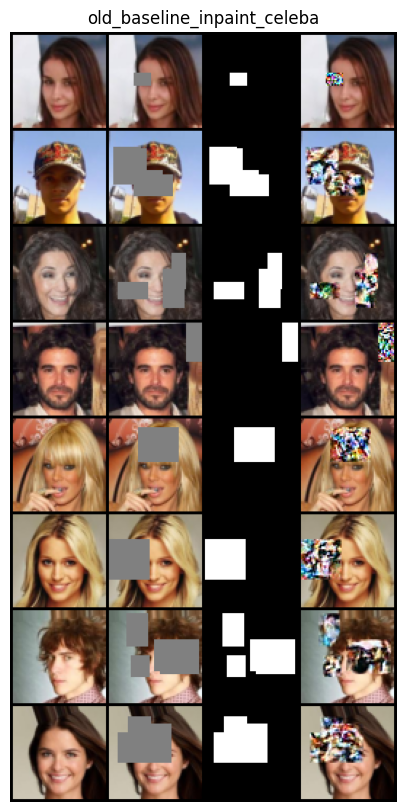

In [25]:
img = Image.open(sample_path)
plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.axis("off")
plt.title(EXP_NAME)
plt.show()

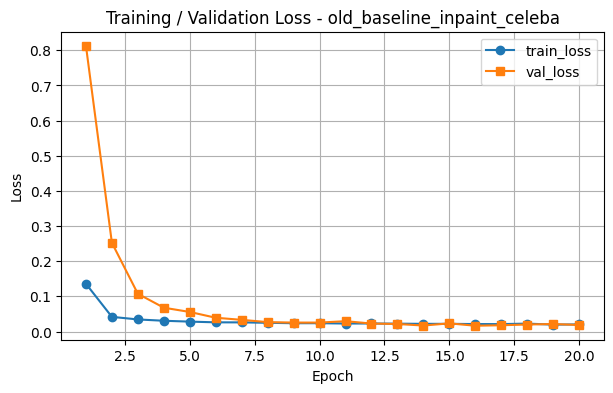

In [26]:
data = load_json(trainlog_path(EXP_NAME), default=[])
df_log = pd.DataFrame(data)

plt.figure(figsize=(7, 4))
plt.plot(df_log["epoch"], df_log["train_loss"], marker="o", label="train_loss")
plt.plot(df_log["epoch"], df_log["val_loss"], marker="s", label="val_loss")
plt.title(f"Training / Validation Loss - {EXP_NAME}")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

In [27]:
all_rows = []

for exp_name in EXPS.keys():
    p = RESULT_DIR / f"{exp_name}_single_eval.json"
    if p.exists():
        data = load_json(p, default=[])
        if isinstance(data, list) and len(data) > 0:
            all_rows.extend(data)

df_all = pd.DataFrame(all_rows)

if len(df_all) > 0:
    baseline_name = "old_baseline_inpaint_celeba"

    if baseline_name in df_all["exp_name"].values:
        baseline_params = float(df_all.loc[df_all["exp_name"] == baseline_name, "params"].iloc[0])
        baseline_macs = float(df_all.loc[df_all["exp_name"] == baseline_name, "macs"].iloc[0])

        df_all["param_reduction_%_vs_baseline"] = (
            (baseline_params - df_all["params"]) / baseline_params * 100
        ).round(2)

        df_all["mac_reduction_%_vs_baseline"] = (
            (baseline_macs - df_all["macs"]) / baseline_macs * 100
        ).round(2)

    combined_csv = RESULT_DIR / "combined_all_experiments.csv"
    combined_json = RESULT_DIR / "combined_all_experiments.json"

    df_all.to_csv(combined_csv, index=False)
    save_json(all_rows, combined_json)

    print(df_all)
    print("Saved:", combined_csv)
    print("Saved:", combined_json)
else:
    print("Only current run result exists, or no saved result files found yet.")

                      exp_name  used_ema    params  params_million  \
0  old_baseline_inpaint_celeba      True  53990019           53.99   

   thop_params        macs  macs_billion       fid  sec_per_img  \
0     53959427  9856548864        9.8565  135.4702      0.23057   

   final_train_loss  final_val_loss  \
0          0.020338        0.018564   

                                         sample_path  \
0  /kaggle/working/cse499b_celeba_inpainting/samp...   

   param_reduction_%_vs_baseline  mac_reduction_%_vs_baseline  
0                            0.0                          0.0  
Saved: /kaggle/working/cse499b_celeba_inpainting/results/combined_all_experiments.csv
Saved: /kaggle/working/cse499b_celeba_inpainting/results/combined_all_experiments.json


In [28]:
# ================================
# FINAL EXPORT CELL (ZIP ALL FILES)
# ================================

import os
import zipfile
from datetime import datetime

# 🔧 Change this to your main working directory
BASE_DIR = "/kaggle/working"

# 📦 Output zip name with timestamp (so no overwrite)
timestamp = datetime.now().strftime("%Y%m%d_%H%M")
ZIP_NAME = f"training_export_{timestamp}.zip"
ZIP_PATH = os.path.join(BASE_DIR, ZIP_NAME)

# 📁 What folders/files to include (modify if needed)
INCLUDE_ITEMS = [
    "checkpoints", 
    "checkpoints_phase3_celeba_compare",
    "results",
    "results_phase3_celeba_compare",
    "samples",
    "samples_phase3_celeba_compare",
    "configs",
    "configs_phase3_celeba_compare",
]

# 📦 Create ZIP
with zipfile.ZipFile(ZIP_PATH, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for item in INCLUDE_ITEMS:
        item_path = os.path.join(BASE_DIR, item)
        
        if os.path.exists(item_path):
            if os.path.isfile(item_path):
                zipf.write(item_path, arcname=item)
            else:
                for root, dirs, files in os.walk(item_path):
                    for file in files:
                        full_path = os.path.join(root, file)
                        rel_path = os.path.relpath(full_path, BASE_DIR)
                        zipf.write(full_path, arcname=rel_path)

print(f"✅ ZIP file created at: {ZIP_PATH}")

✅ ZIP file created at: /kaggle/working/training_export_20260407_1159.zip


In [29]:
# Optional cleanup cell to save storage after evaluation
# Use this only if you want to remove the latest checkpoint and keep best + ema

p = latest_full_path(EXP_NAME)
if Path(p).exists():
    Path(p).unlink()
    print("Deleted:", p)
else:
    print("Latest checkpoint not found.")

Deleted: /kaggle/working/cse499b_celeba_inpainting/checkpoints/old_baseline_inpaint_celeba_latest_full.pt
